In [36]:
!pip install prophet pandas matplotlib



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt


In [38]:
file_path = r"C:\Users\adity\Downloads\MMDS\Project\Final_Processed.csv"
df = pd.read_csv(file_path)

df.head()


,ride_id,datetime,ride_status,pickup_area,drop_area,year,month,day,hour,date,time_zone,demand,available_cabs,shortage
0,BKG002834,2024-01-01T14:59:00.000Z,Success,Anekal,Bellandur,2024,1,1,14,2024-01-01,midday,16,24,-8
1,BKG004040,2024-01-01T12:47:00.000Z,Cancelled by Driver,Anekal,Yeshwanthpur,2024,1,1,12,2024-01-01,midday,16,24,-8
2,BKG034183,2024-01-01T14:38:00.000Z,Success,Anekal,RT Nagar,2024,1,1,14,2024-01-01,midday,16,24,-8
3,BKG042360,2024-01-01T13:34:00.000Z,Success,Anekal,Kengeri,2024,1,1,13,2024-01-01,midday,16,24,-8
4,BKG059450,2024-01-01T14:30:00.000Z,Cancelled by Driver,Anekal,Magadi Road,2024,1,1,14,2024-01-01,midday,16,24,-8


In [39]:
df['datetime'] = pd.to_datetime(df['datetime'], utc=True)
df['datetime'] = df['datetime'].dt.tz_localize(None)


In [40]:
df_hourly = df.groupby(pd.Grouper(key='datetime', freq='h')).agg({
    'available_cabs': 'max'
}).reset_index()

df_hourly = df_hourly.dropna()
df_hourly.head()


,datetime,available_cabs
0,2024-01-01 00:00:00,43.0
1,2024-01-01 01:00:00,43.0
2,2024-01-01 02:00:00,43.0
3,2024-01-01 03:00:00,43.0
4,2024-01-01 04:00:00,43.0


In [41]:
max_cabs = df['available_cabs'].max() + 20

prophet_df = df_hourly.rename(columns={
    'datetime': 'ds',
    'available_cabs': 'y'
})

prophet_df['floor'] = 0
prophet_df['cap'] = max_cabs


In [42]:
model = Prophet(
    growth="logistic",
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True,
    seasonality_mode="multiplicative",
    changepoint_prior_scale=0.8,
    seasonality_prior_scale=15
)

model.fit(prophet_df)


01:10:34 - cmdstanpy - INFO - Chain [1] start processing
01:10:38 - cmdstanpy - INFO - Chain [1] done processing


In [43]:
future = model.make_future_dataframe(periods=365 * 24, freq='h')

future['floor'] = 0
future['cap'] = max_cabs

forecast = model.predict(future)

forecast['yhat_int'] = forecast['yhat'].round().astype(int)
forecast['yhat_int'] = forecast['yhat_int'].clip(lower=0)


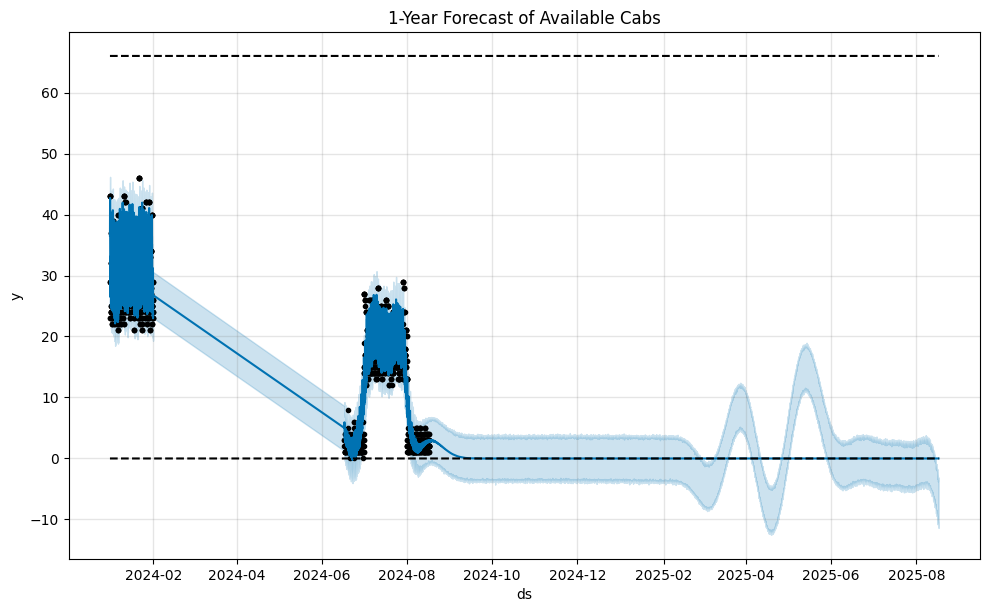

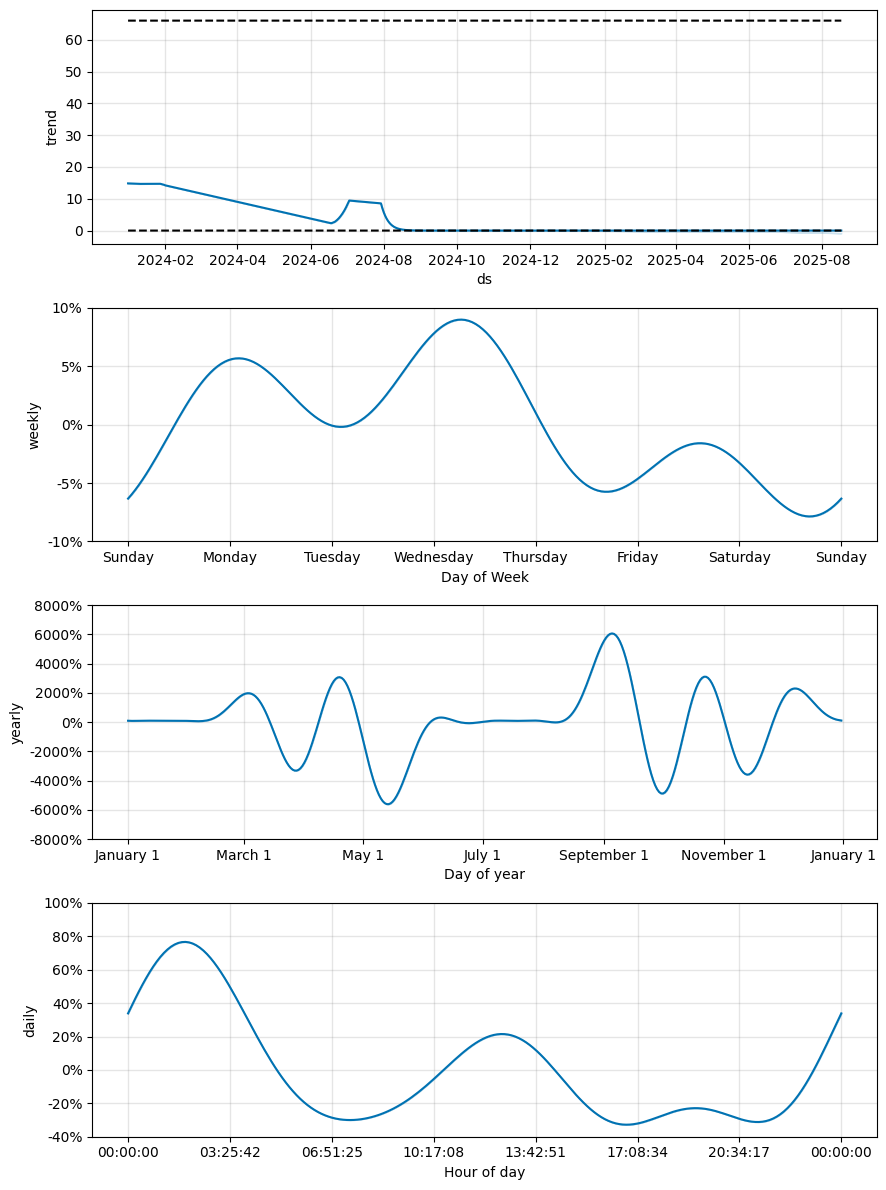

In [44]:
model.plot(forecast)
plt.title("1-Year Forecast of Available Cabs")
plt.show()

model.plot_components(forecast)
plt.show()


In [51]:
user_input = input("Enter any date & time within the next year (YYYY-MM-DD HH:MM:SS): ")

try:
    query_time = pd.to_datetime(user_input)

    nearest_time = forecast.iloc[
        (forecast['ds'] - query_time).abs().argsort()[:1]
    ]['ds'].values[0]

    result = forecast[forecast['ds'] == nearest_time]
    predicted = int(result['yhat_int'].values[0])

    print(f"\nClosest forecast timestamp: {nearest_time}")
    print(f"🔮 Predicted available cabs at {query_time}: {predicted}")

    display(result[['ds', 'yhat_int', 'yhat_lower', 'yhat_upper']])

except Exception as e:
    print("\n❌ Invalid input. Use format YYYY-MM-DD HH:MM:SS.")
    print("Error:", e)


Closest forecast timestamp: 2025-08-16 23:00:00
Predicted cabs: 0


C:\Users\adity\AppData\Local\Temp\ipykernel_1608\188537967.py:5: FutureWarning: The behavior of Series.argsort in the presence of NA values is deprecated. In a future version, NA values will be ordered last instead of set to -1.
  nearest_time = forecast.iloc[(forecast['ds'] - query_time).abs().argsort()[0]]['ds']


,ds,yhat_int,yhat_lower,yhat_upper
10967,2025-08-16 23:00:00,0,-11.37526,-3.754541


In [46]:
df_hourly.tail(200)


,datetime,available_cabs
5296,2024-08-08 16:00:00,2.0
5297,2024-08-08 17:00:00,2.0
5298,2024-08-08 18:00:00,2.0
5299,2024-08-08 19:00:00,2.0
5300,2024-08-08 20:00:00,1.0
...,...,...
5491,2024-08-16 19:00:00,2.0
5492,2024-08-16 20:00:00,2.0
5493,2024-08-16 21:00:00,4.0
5494,2024-08-16 22:00:00,2.0
